# 03 - Modeling

Cleaned dataset ->  model-ready train/test data, then train and evaluate a **Logistic Regression** model for
credit-risk classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve)

sns.set_style("whitegrid")
%matplotlib inline
RANDOM_STATE = 42

## 1. Load data and define features / target

`age_group` is dropped here - it's just a bucketed version of `age`, no need for model train

In [2]:
df = pd.read_csv("../data/processed/german_credit_processed.csv")
model_df = df.drop(columns=["age_group"])

y = (model_df["risk"] == "Bad").astype(int)  # 1 = Bad risk, 0 = Good risk
X = model_df.drop(columns=["risk"])

numeric_features = ["duration_months", "credit_amount", "installment_rate", "residence_since",
                     "age", "existing_credits", "num_dependents", "credit_per_month"]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nX shape:", X.shape, " y shape:", y.shape)

Numeric features: ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'credit_per_month']

Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

X shape: (1000, 21)  y shape: (1000,)


## 2. Train / test split

A **stratified** split keeps the 70/30 Good/Bad ratio the same in both the train
and test sets. Without that, a random split could hand the test set a different
class mix than training, which would make the evaluation less trustworthy.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train bad-risk rate: %.3f" % y_train.mean())
print("Test bad-risk rate: %.3f" % y_test.mean())

Train shape: (800, 21)  Test shape: (200, 21)
Train bad-risk rate: 0.300
Test bad-risk rate: 0.300


## 3. Save the model-ready data

Writing the split out to its own files makes the train/test data reusable without
re-running the split every time - and it's a natural checkpoint in the pipeline
between the cleaned dataset and the trained model.

In [4]:
train_set = X_train.copy()
train_set["risk"] = y_train
test_set = X_test.copy()
test_set["risk"] = y_test

train_set.to_csv("../data/processed/train_set.csv", index=False)
test_set.to_csv("../data/processed/test_set.csv", index=False)

print("Saved train_set.csv:", train_set.shape)
print("Saved test_set.csv:", test_set.shape)

Saved train_set.csv: (800, 22)
Saved test_set.csv: (200, 22)


## 4. Preprocessing pipeline

- **Numeric features** get `StandardScaler` - logistic regression is sensitive to
  feature scale, and credit amount / duration are on very different scales from
  each other.
- **Categorical features** get `OneHotEncoder`. `handle_unknown="ignore"` keeps the
  model from breaking if it ever sees a category at prediction time that wasn't in
  the training data.

The pipeline is fit only on `X_train`, so none of the test set leaks into
preprocessing.

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

## 5. Train the model

`class_weight="balanced"` tells the model to pay more attention to the minority
class (Bad risk, 30% of the data) while training.

In [6]:
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 6. Evaluation

missing a Bad-risk customer is usually
more costly than being overly cautious about a Good one, so **recall and precision
on the Bad class, F1, and ROC-AUC** tell us a lot more than accuracy alone.

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (Bad)": precision_score(y_test, y_pred),
    "Recall (Bad)": recall_score(y_test, y_pred),
    "F1 (Bad)": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
}

for name, value in metrics.items():
    print(f"{name}: {value:.3f}")

print()
print(classification_report(y_test, y_pred, target_names=["Good", "Bad"]))

Accuracy: 0.760
Precision (Bad): 0.570
Recall (Bad): 0.817
F1 (Bad): 0.671
ROC-AUC: 0.807

              precision    recall  f1-score   support

        Good       0.90      0.74      0.81       140
         Bad       0.57      0.82      0.67        60

    accuracy                           0.76       200
   macro avg       0.74      0.78      0.74       200
weighted avg       0.80      0.76      0.77       200



## 7. Confusion matrix

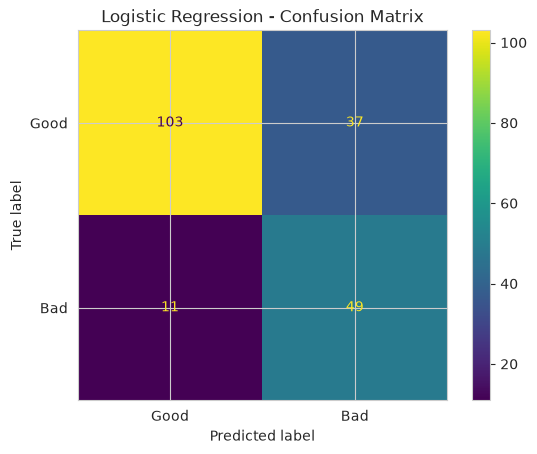

In [8]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Good", "Bad"])
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Out of 60 Bad-risk customers in the test set, the model catches most of them
(recall ~82%), at the cost of flagging a fair number of Good-risk customers as
risky too. In practice, a model like this is best used to flag applications for a
human to take a closer look at - not to auto-decline anyone.

## 8. ROC curve

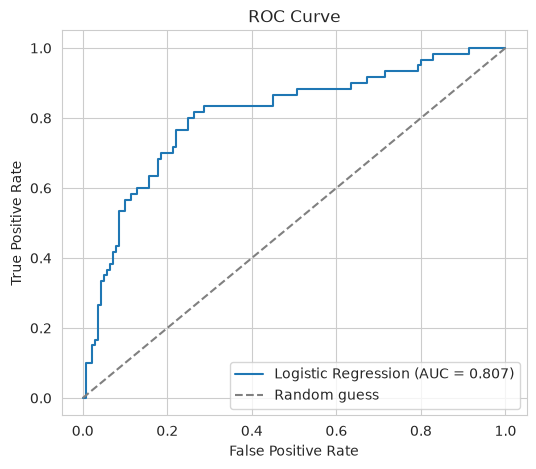

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

An AUC of ~0.81 means the model is fairly good, but not perfect

## 9. Coefficients - what's driving the predictions

Coefficients show direction and relative strength, not proof of cause and effect -
they describe an association picked up from this specific dataset.

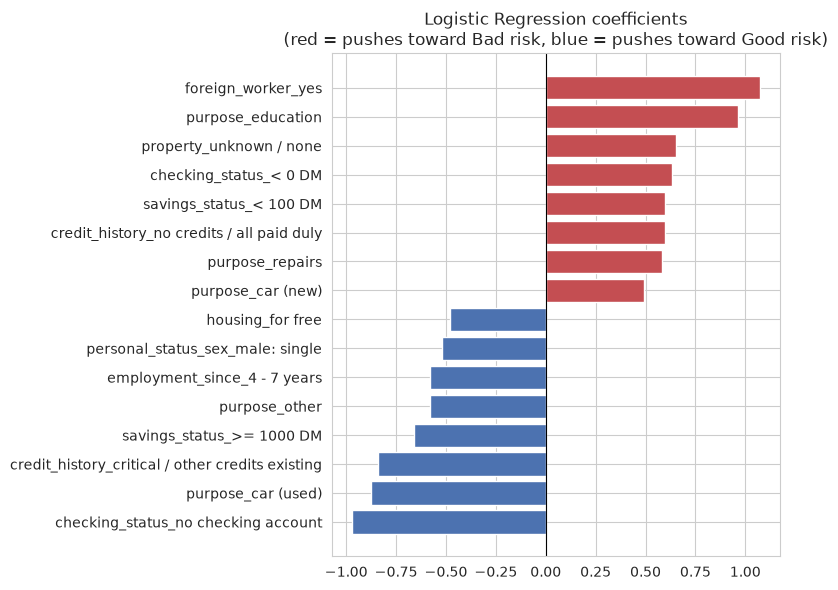

In [10]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["feature"] = coef_df["feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)

top_bad = coef_df.sort_values("coefficient", ascending=False).head(8)
top_good = coef_df.sort_values("coefficient").head(8)
plot_df = pd.concat([top_bad, top_good]).sort_values("coefficient")

plt.figure(figsize=(8, 6))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in plot_df["coefficient"]]
plt.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients\n(red = pushes toward Bad risk, blue = pushes toward Good risk)")
plt.tight_layout()
plt.show()

A few things stand out:

- **`checking_status_no checking account`** has one of the largest *negative*
  coefficients - associated with **lower** risk. Matches the EDA: not having a
  checking account on record isn't the same as being risky in this dataset, likely
  a reflection of how this applicant pool was originally screened.
- **`credit_history_critical / other credits existing`** and **`purpose_car
  (used)`** also lean toward lower risk, again matching the EDA.
- **`foreign_worker_yes`** has the single largest positive coefficient, but worth a
  caution flag: only 37 of 1,000 customers are `foreign_worker = "no"`, so that
  comparison is based on a very small group and shouldn't be treated as a solid
  finding on its own.

## Summary

- A Logistic Regression model with `class_weight="balanced"` reaches **~76%
  accuracy, 82% recall on Bad risk, and a 0.81 ROC-AUC** on the held-out test set.
- **Checking account status, credit history, and loan purpose** are the strongest,
  most explainable drivers of predicted risk.
- The model is a reasonable decision-support tool for flagging applications for
  review - it isn't accurate or robust enough (nor is that the goal here) to
  replace human judgment on an actual lending decision.